In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [3]:

eeg = loadmat("../Dataset/dataset.mat")
rating = loadmat("../Dataset/rating.mat")
classes = loadmat("../Dataset/class_012.mat")

In [4]:
print(eeg.keys())
print(rating.keys())
print(classes.keys())

dict_keys(['__header__', '__version__', '__globals__', 'dataset'])
dict_keys(['__header__', '__version__', '__globals__', 'rating'])
dict_keys(['__header__', '__version__', '__globals__', 'class_012'])


| **Key**       | **Description**                                                                                    | **Purpose**                                                                |
| ------------- | -------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| `__header__`  | Contains metadata about the MATLAB file, such as the MATLAB version and file creation information. | Provides file information; not used in EEG analysis.                       |
| `__version__` | Stores the MATLAB file format version.                                                             | Indicates which MATLAB version was used to save the file.                  |
| `__globals__` | Contains global MATLAB variables (usually empty).                                                  | Generally not used for EEG analysis.                                       |
| `dataset`     | Contains the actual EEG recordings.                                                                | Main EEG data used for preprocessing, visualization, and machine learning. |
| `rating`      | Contains the participants' self-reported workload ratings (values from 4 to 9).                    | Used as the ground truth workload scores.                                  |
| `class_012`   | Contains the workload class labels for each participant (0 = Low, 1 = Medium, 2 = High).           | Used as target labels for classification models.                           |


In [5]:
print(eeg['dataset'].shape)
print(rating['rating'].shape)
print(classes['class_012'].shape)

(14, 19200, 45)
(45, 1)
(45, 1)


| File            | Shape               | Meaning                                            |
| --------------- | ------------------- | -------------------------------------------------- |
| `dataset.mat`   | **(14, 19200, 45)** | 14 EEG channels × 19,200 samples × 45 participants |
| `rating.mat`    | **(45, 1)**         | Self-reported workload rating for each participant |
| `class_012.mat` | **(45, 1)**         | Workload class label for each participant          |


In [6]:
print(rating['rating'])

[[8]
 [5]
 [5]
 [5]
 [7]
 [5]
 [7]
 [7]
 [6]
 [5]
 [6]
 [7]
 [7]
 [6]
 [9]
 [9]
 [7]
 [5]
 [8]
 [6]
 [8]
 [5]
 [4]
 [8]
 [4]
 [7]
 [6]
 [8]
 [6]
 [7]
 [5]
 [9]
 [4]
 [8]
 [8]
 [5]
 [8]
 [5]
 [6]
 [7]
 [8]
 [8]
 [7]
 [8]
 [7]]


In [7]:
print(classes['class_012'])

[[2]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [0]
 [2]
 [1]
 [2]
 [0]
 [0]
 [2]
 [0]
 [1]
 [1]
 [2]
 [1]
 [1]
 [0]
 [2]
 [0]
 [2]
 [2]
 [0]
 [2]
 [0]
 [1]
 [1]
 [2]
 [2]
 [1]
 [2]
 [1]]


In [8]:
print(eeg['dataset'])

[[[4584.62 4663.59 4212.82 ... 4233.33 4502.05 4105.13]
  [4584.1  4663.59 4213.85 ... 4225.13 4502.05 4109.23]
  [4574.36 4658.46 4228.21 ... 4213.85 4496.41 4115.9 ]
  ...
  [4605.64 4717.95 4168.72 ... 4216.41 4523.59 4227.18]
  [4606.15 4736.92 4186.67 ... 4220.51 4518.46 4223.59]
  [4611.28 4746.15 4202.05 ... 4231.79 4517.95 4215.38]]

 [[3902.05 3978.46 4148.72 ... 4220.   4781.03 4028.72]
  [3895.9  3965.64 4151.28 ... 4206.67 4778.46 4027.69]
  [3893.85 3965.64 4155.38 ... 4194.87 4769.23 4029.23]
  ...
  [3987.69 4144.62 4217.44 ... 4201.54 4770.77 4101.54]
  [3992.82 4164.1  4224.62 ... 4202.56 4773.33 4098.46]
  [4001.54 4134.36 4231.79 ... 4206.15 4779.49 4086.15]]

 [[4571.79 4641.03 3766.15 ... 3715.9  4411.79 4111.79]
  [4574.87 4643.08 3768.21 ... 3715.9  4412.31 4121.54]
  [4576.92 4641.54 3776.92 ... 3710.77 4407.18 4119.49]
  ...
  [4573.85 4631.28 3753.33 ... 3795.38 4452.82 4145.13]
  [4572.82 4636.92 3770.26 ... 3796.41 4447.18 4135.9 ]
  [4579.49 4631.79 3781.03

In [9]:
subject1 = eeg['dataset'][:, :, 0]

In [10]:
print(subject1.shape)

(14, 19200)


This means:

- 14 EEG channels
- 19,200 samples
- for Participant 1

In [11]:
print(eeg['dataset'].shape)
print(rating['rating'].shape)
print(classes['class_012'].shape)

print(rating['rating'])
print(classes['class_012'])

(14, 19200, 45)
(45, 1)
(45, 1)
[[8]
 [5]
 [5]
 [5]
 [7]
 [5]
 [7]
 [7]
 [6]
 [5]
 [6]
 [7]
 [7]
 [6]
 [9]
 [9]
 [7]
 [5]
 [8]
 [6]
 [8]
 [5]
 [4]
 [8]
 [4]
 [7]
 [6]
 [8]
 [6]
 [7]
 [5]
 [9]
 [4]
 [8]
 [8]
 [5]
 [8]
 [5]
 [6]
 [7]
 [8]
 [8]
 [7]
 [8]
 [7]]
[[2]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [0]
 [2]
 [1]
 [2]
 [0]
 [0]
 [2]
 [0]
 [1]
 [1]
 [2]
 [1]
 [1]
 [0]
 [2]
 [0]
 [2]
 [2]
 [0]
 [2]
 [0]
 [1]
 [1]
 [2]
 [2]
 [1]
 [2]
 [1]]


In [12]:
print(rating['rating'].T)
print(classes['class_012'].T)

[[8 5 5 5 7 5 7 7 6 5 6 7 7 6 9 9 7 5 8 6 8 5 4 8 4 7 6 8 6 7 5 9 4 8 8 5
  8 5 6 7 8 8 7 8 7]]
[[2 0 0 0 1 0 1 1 1 0 1 1 1 1 2 2 1 0 2 1 2 0 0 2 0 1 1 2 1 1 0 2 0 2 2 0
  2 0 1 1 2 2 1 2 1]]


| File              | Shape           | Description                  |
| ----------------- | --------------- | ---------------------------- |
| **dataset.mat**   | (14, 19200, 45) | EEG signals                  |
| **rating.mat**    | (45, 1)         | Workload ratings (4–9)       |
| **class_012.mat** | (45, 1)         | Three-class labels (0, 1, 2) |


In [13]:
X = eeg["dataset"]

y = rating["rating"]

In [14]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Why is EEG stored as a NumPy array? 
- EEG is stored as a NumPy array because it is numerical, multi-dimensional data, and NumPy is the standard Python library for efficiently storing and processing large numerical datasets.

In [15]:
print(X.shape)

print(y.shape)

(14, 19200, 45)
(45, 1)


In [16]:
sampling_rate = 128

duration = X.shape[1] / sampling_rate

print(duration)

150.0


In [17]:
print(y)

[[8]
 [5]
 [5]
 [5]
 [7]
 [5]
 [7]
 [7]
 [6]
 [5]
 [6]
 [7]
 [7]
 [6]
 [9]
 [9]
 [7]
 [5]
 [8]
 [6]
 [8]
 [5]
 [4]
 [8]
 [4]
 [7]
 [6]
 [8]
 [6]
 [7]
 [5]
 [9]
 [4]
 [8]
 [8]
 [5]
 [8]
 [5]
 [6]
 [7]
 [8]
 [8]
 [7]
 [8]
 [7]]


In [18]:
np.unique(y)

array([4, 5, 6, 7, 8, 9], dtype=uint8)

In [19]:
binary_labels = np.where(y <= 6, 0, 1)

In [20]:
print(binary_labels)

[[1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [21]:
unique, counts = np.unique(binary_labels, return_counts=True)

print(dict(zip(unique, counts)))

{np.int64(0): np.int64(20), np.int64(1): np.int64(25)}


- 20 Low Workload subjects
- 25 High Workload subjects

In [22]:
np.save("binary_labels.npy", binary_labels)

| Question                                 | Answer                                                                                                                                |
| ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| Why is the subject dimension last?       | It is the organization chosen by the dataset creators in MATLAB, allowing each subject's EEG recording to be accessed as a 2D matrix. |
| Could the shape be 45 × 14 × 19200?      | Yes. The data can be reordered, and deep learning frameworks often prefer this format.                                                |
| Why 128 Hz?                              | The Emotiv EPOC headset samples at 128 times per second, which is sufficient for capturing important EEG frequency bands.             |
| Why 150 seconds?                         | Because 19,200 samples recorded at 128 Hz correspond to 150 seconds (2.5 minutes).                                                    |
| Why are ratings subjective?              | They are based on participants' perceived mental workload after the task.                                                             |
| Could two people have different ratings? | Yes. Individual differences such as experience, stress, and cognitive ability influence perceived workload.                           |
| Why choose 6 as the threshold?           | It follows the labeling strategy used in previous STEW studies, enabling fair comparison with published work.                         |
| Could another threshold work?            | Yes, but it would change the class definitions and reduce comparability with prior research.                                          |
| Are both classes equally represented?    | They are not perfectly equal but are reasonably balanced (20 low vs. 25 high).                                                        |
| Should class balancing be applied?       | Not initially. The slight imbalance is unlikely to bias the models significantly.                                                     |


## Module 2: EEG Signal Visualization

Plot One EEG Channel


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling frequency of STEW dataset
fs = 128

# Subject 1 = index 0
subject_idx = 0

# AF3 = channel index 0
channel_idx = 0

# Extract the complete AF3 signal for Subject 1
signal = X[channel_idx, :, subject_idx]

print("Signal shape:", signal.shape)
print("Number of samples:", len(signal))

# Create time axis in seconds
time = np.arange(len(signal)) / fs

print("Recording duration:", len(signal) / fs, "seconds")

Signal shape: (19200,)
Number of samples: 19200
Recording duration: 150.0 seconds


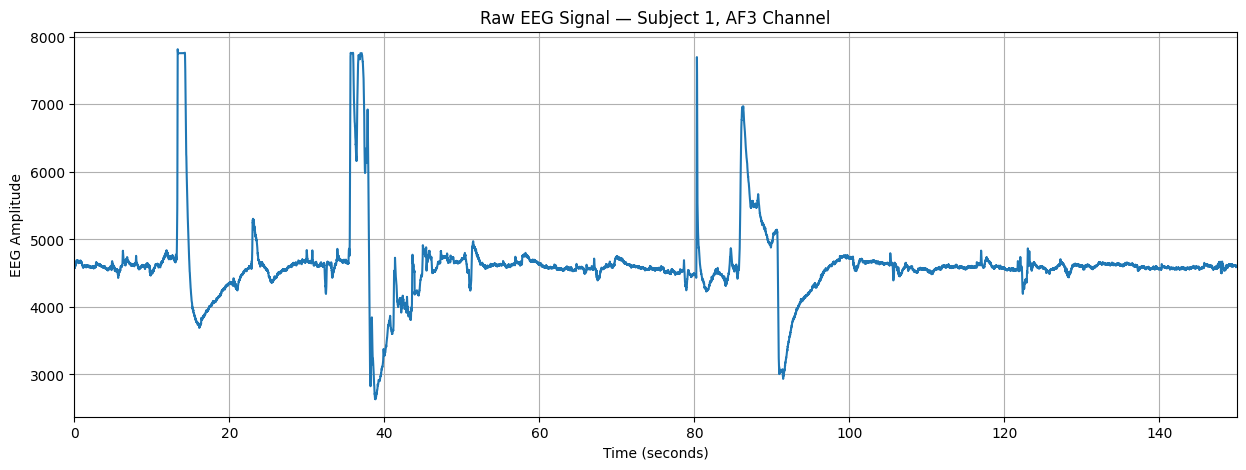

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(time, signal)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw EEG Signal — Subject 1, AF3 Channel")

plt.xlim(0, 150)
plt.grid(True)

plt.show()

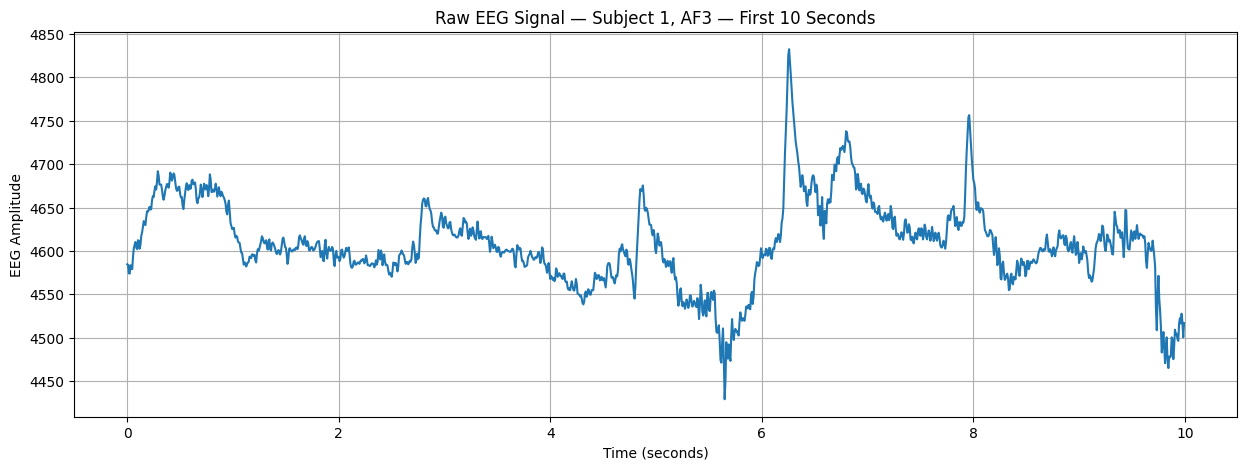

In [25]:
start_time = 0
end_time = 10

start_sample = start_time * fs
end_sample = end_time * fs

plt.figure(figsize=(15, 5))

plt.plot(
    time[start_sample:end_sample],
    signal[start_sample:end_sample]
)

plt.xlabel("Time (seconds)")
plt.ylabel("EEG Amplitude")
plt.title("Raw EEG Signal — Subject 1, AF3 — First 10 Seconds")

plt.grid(True)
plt.show()

Plot Multiple Channels

In [26]:
import numpy as np
import matplotlib.pyplot as plt

fs = 128
subject_idx = 0

channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

In [27]:
selected_channels = ["AF3", "F3", "F4", "AF4"]

time = np.arange(X.shape[1]) / fs

plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

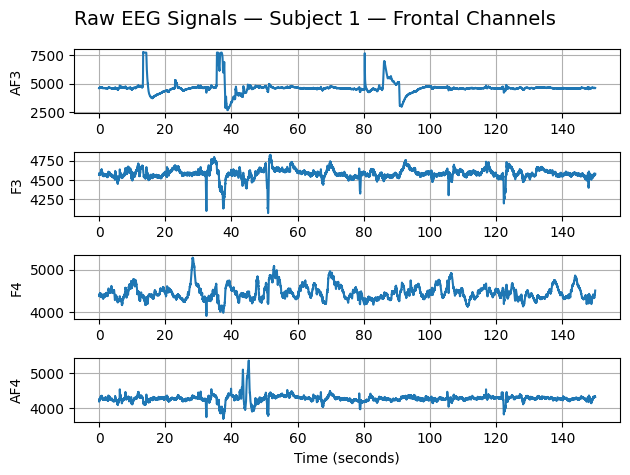

In [28]:
for i, channel in enumerate(selected_channels):
    channel_idx = channel_names.index(channel)
    signal = X[channel_idx, :, subject_idx]

    plt.subplot(4, 1, i + 1)
    plt.plot(time, signal)
    plt.ylabel(channel)
    plt.grid(True)

plt.xlabel("Time (seconds)")
plt.suptitle(
    "Raw EEG Signals — Subject 1 — Frontal Channels",
    fontsize=14
)

plt.tight_layout()
plt.show()

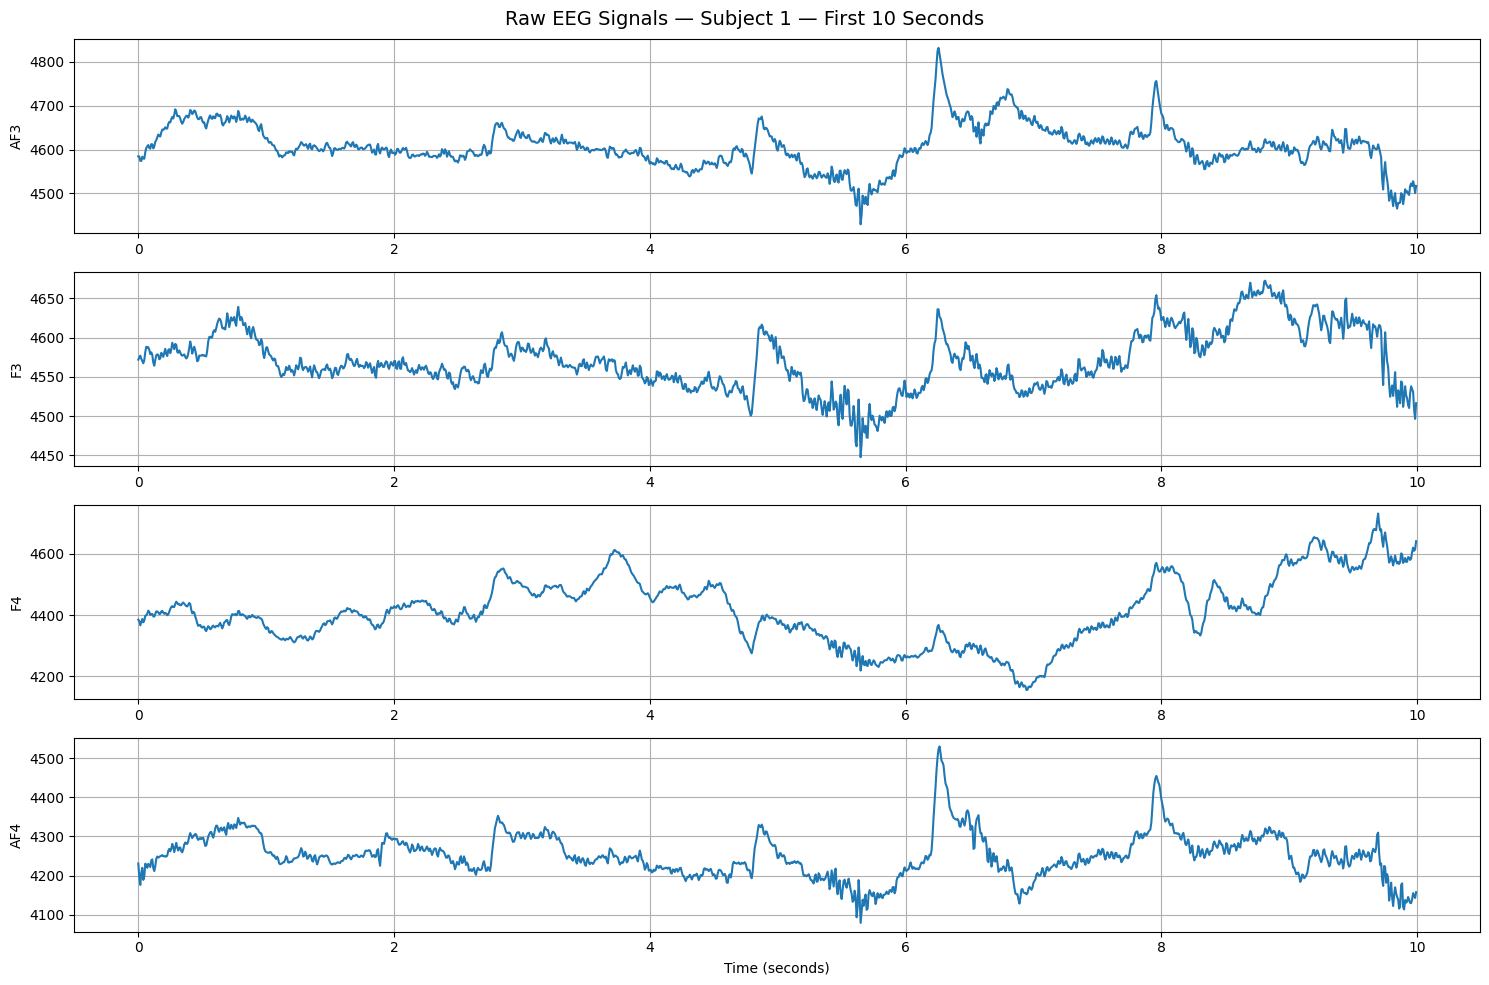

In [29]:
start_time = 0
end_time = 10

start_sample = start_time * fs
end_sample = end_time * fs

plt.figure(figsize=(15, 10))

for i, channel in enumerate(selected_channels):
    channel_idx = channel_names.index(channel)

    signal = X[
        channel_idx,
        start_sample:end_sample,
        subject_idx
    ]

    time_10s = np.arange(len(signal)) / fs

    plt.subplot(4, 1, i + 1)
    plt.plot(time_10s, signal)

    plt.ylabel(channel)
    plt.grid(True)

plt.xlabel("Time (seconds)")
plt.suptitle(
    "Raw EEG Signals — Subject 1 — First 10 Seconds",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [30]:
for channel in selected_channels:
    idx = channel_names.index(channel)
    signal = X[idx, :, subject_idx]

    print(
        channel,
        "| Mean:", np.mean(signal),
        "| Std:", np.std(signal),
        "| Range:", np.ptp(signal)
    )

AF3 | Mean: 4613.7930671875 | Std: 563.3378496936378 | Range: 5183.08
F3 | Mean: 4580.4351703125 | Std: 68.17970278748466 | Range: 753.8499999999999
F4 | Mean: 4450.8990786458335 | Std: 169.15080507700216 | Range: 1384.6200000000003
AF4 | Mean: 4265.2400265625 | Std: 108.15949962485152 | Range: 1670.7699999999995


Task 3: Compare Two Subjects

Task 3A: Full 150-second comparison

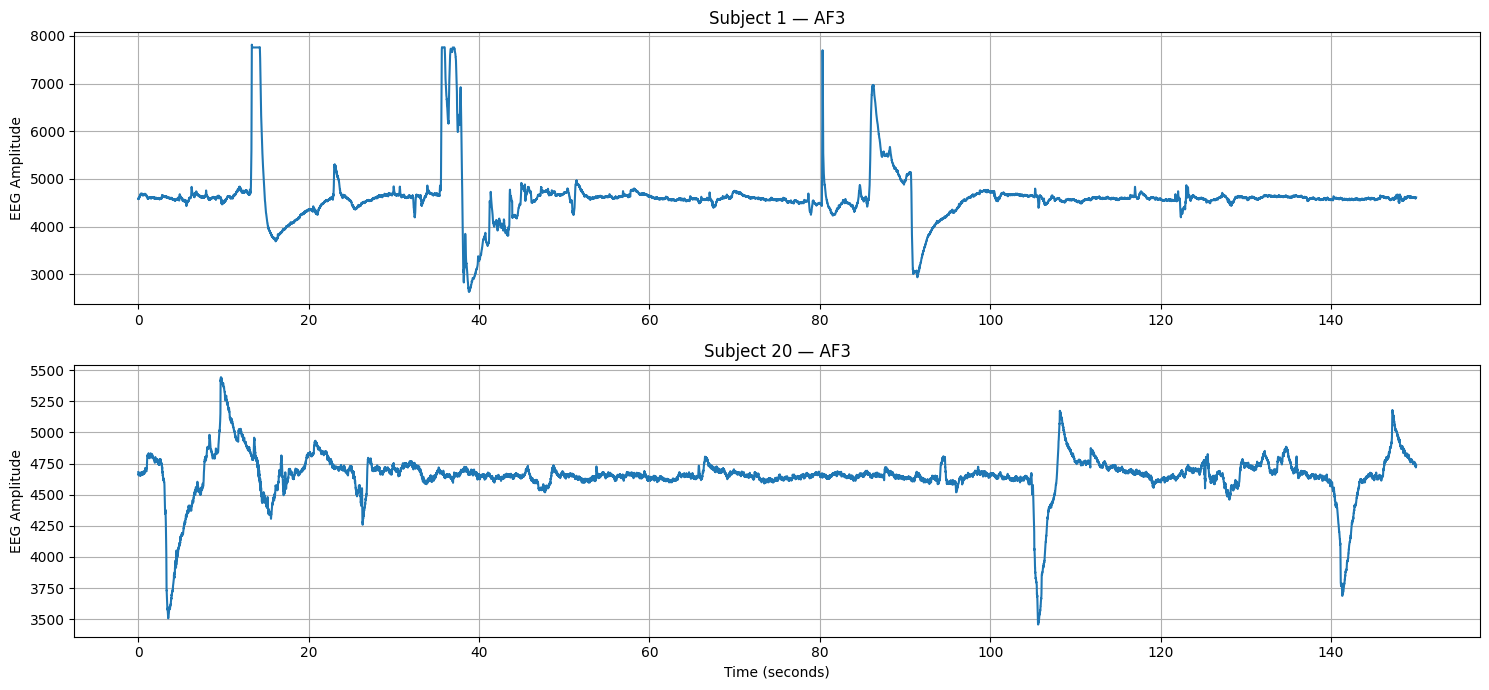

In [31]:
import numpy as np
import matplotlib.pyplot as plt

fs = 128

channel_idx = 0       # AF3
subject1_idx = 0      # Subject 1
subject20_idx = 19    # Subject 20

signal_s1 = X[channel_idx, :, subject1_idx]
signal_s20 = X[channel_idx, :, subject20_idx]

time = np.arange(X.shape[1]) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(time, signal_s1)
axes[0].set_title("Subject 1 — AF3")
axes[0].set_ylabel("EEG Amplitude")
axes[0].grid(True)

axes[1].plot(time, signal_s20)
axes[1].set_title("Subject 20 — AF3")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("EEG Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Task 3B: Compare the first 10 seconds

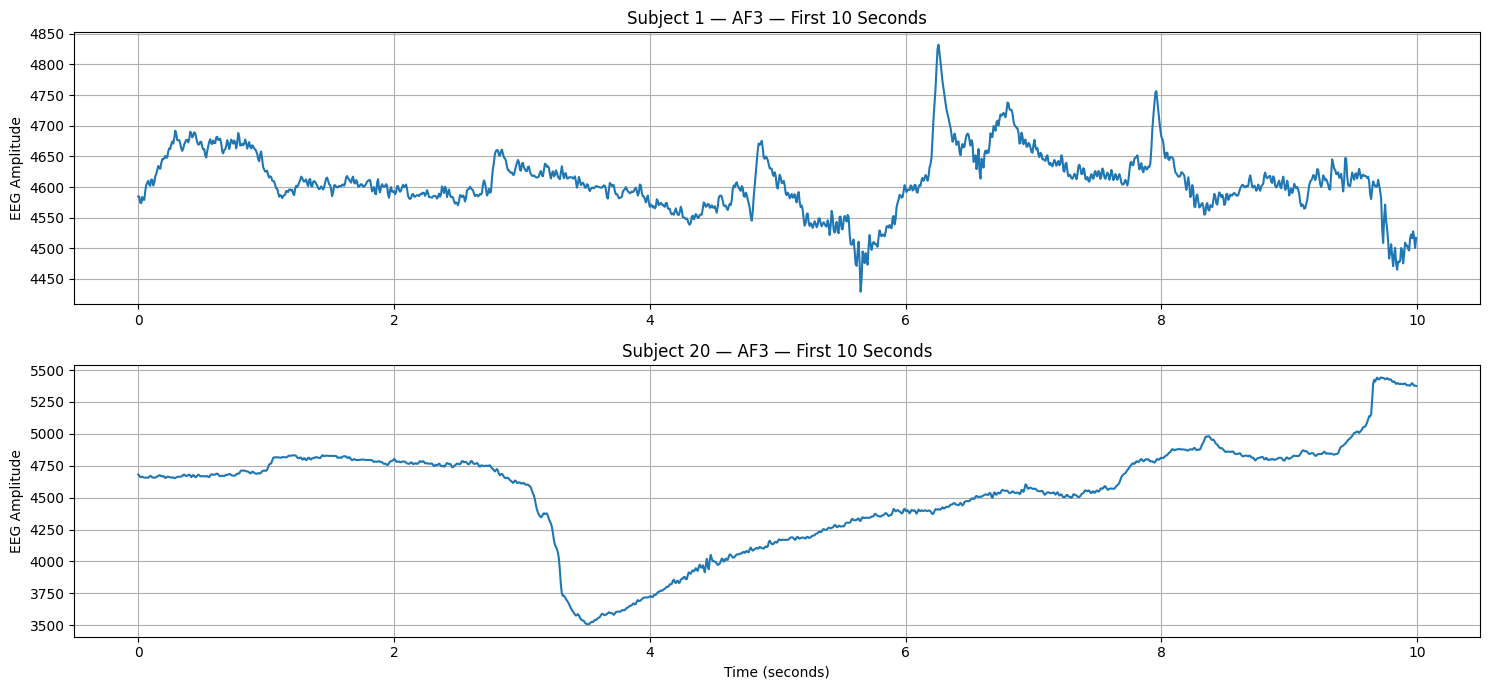

In [32]:
end_time = 10
end_sample = end_time * fs

time_10s = np.arange(end_sample) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

axes[0].plot(
    time_10s,
    signal_s1[:end_sample]
)

axes[0].set_title("Subject 1 — AF3 — First 10 Seconds")
axes[0].set_ylabel("EEG Amplitude")
axes[0].grid(True)

axes[1].plot(
    time_10s,
    signal_s20[:end_sample]
)

axes[1].set_title("Subject 20 — AF3 — First 10 Seconds")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("EEG Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Task 3C: Calculate basic statistics

In [33]:
print("Subject 1 — AF3")
print("Mean:", np.mean(signal_s1))
print("Std:", np.std(signal_s1))
print("Range:", np.ptp(signal_s1))

print("\nSubject 20 — AF3")
print("Mean:", np.mean(signal_s20))
print("Std:", np.std(signal_s20))
print("Range:", np.ptp(signal_s20))

Subject 1 — AF3
Mean: 4613.7930671875
Std: 563.3378496936378
Range: 5183.08

Subject 20 — AF3
Mean: 4651.373036458334
Std: 189.4907518023327
Range: 1983.0800000000004


In [34]:
print("Subject 1 rating:", y[0, 0])
print("Subject 20 rating:", y[19, 0])

print("Subject 1 binary class:", binary_labels[0, 0])
print("Subject 20 binary class:", binary_labels[19, 0])

Subject 1 rating: 8
Subject 20 rating: 6
Subject 1 binary class: 1
Subject 20 binary class: 0


Task 4: Understand EEG Channels

Task 5: Learn EEG Frequency Bands

Task 7: Dataset Statistics

In [35]:
import numpy as np
import pandas as pd

channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

channel_stats = []

for i, channel in enumerate(channel_names):

    # All time samples and all subjects for this channel
    data = X[i, :, :]

    channel_stats.append({
        "Channel": channel,
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Variance": np.var(data),
        "Minimum": np.min(data),
        "Maximum": np.max(data)
    })

channel_stats_df = pd.DataFrame(channel_stats)

print(channel_stats_df)

   Channel         Mean         Std       Variance   Minimum  Maximum
0      AF3  4385.925290  296.195632   87731.852358  131.7950  7956.92
1       F7  4177.585540  312.575516   97703.453114  316.9230  8244.10
2       F3  4281.642313  407.562538  166107.222564  515.3850  8055.38
3      FC5  4233.815741  280.404325   78626.585336    0.0000  8294.36
4       T7  4497.664683  439.786994  193412.599962  339.4870  8247.18
5       P7  4326.095806  394.421195  155568.078987  332.3080  8100.51
6       O1  4379.517038  241.653082   58396.211831  198.4620  8394.87
7       O2  4245.593013  280.969270   78943.730594   50.2564  8401.54
8       P8  4211.899773  390.407498  152418.014558    0.0000  8401.54
9       T8  4252.846172  315.003725   99227.346610   21.0256  8401.54
10     FC6  4289.619384  263.371681   69364.642592    0.0000  8401.54
11      F4  4522.474289  261.507465   68386.154291    2.5641  8401.54
12      F8  4428.391734  290.739274   84529.325417    0.0000  8401.54
13     AF4  4432.601

In [36]:
highest_variance = channel_stats_df.loc[
    channel_stats_df["Variance"].idxmax()
]

lowest_variance = channel_stats_df.loc[
    channel_stats_df["Variance"].idxmin()
]

print("\nHighest Variance Channel:")
print(highest_variance)

print("\nLowest Variance Channel:")
print(lowest_variance)


Highest Variance Channel:
Channel                T7
Mean          4497.664683
Std            439.786994
Variance    193412.599962
Minimum           339.487
Maximum           8247.18
Name: 4, dtype: object

Lowest Variance Channel:
Channel               O1
Mean         4379.517038
Std           241.653082
Variance    58396.211831
Minimum          198.462
Maximum          8394.87
Name: 6, dtype: object


In [37]:
subject_stats = []

for subject_idx in range(X.shape[2]):

    # All channels and all time samples for one subject
    data = X[:, :, subject_idx]

    subject_stats.append({
        "Subject": subject_idx + 1,
        "Mean": np.mean(data),
        "Std": np.std(data),
        "Minimum": np.min(data),
        "Maximum": np.max(data)
    })

subject_stats_df = pd.DataFrame(subject_stats)

print(subject_stats_df)

    Subject         Mean         Std    Minimum  Maximum
0         1  4337.274097  341.792030  2633.3300  7816.41
1         2  4348.313532  280.847782  2837.4400  6225.64
2         3  4313.484762  303.446662  3646.1500  5336.41
3         4  4356.995956  266.537782  3048.7200  5977.95
4         5  4213.958327  262.079016  3524.6200  5275.38
5         6  4229.944901  265.975617  3028.2100  7956.92
6         7  4522.743836  177.793378  2265.6400  8024.62
7         8  4345.332754  254.786151  3768.7200  6492.82
8         9  4351.033228  252.879427  3781.0300  6853.33
9        10  4346.879700  275.143093  2709.7400  7518.97
10       11  4219.742262  293.735403  2597.4400  6945.13
11       12  4225.712791  464.705611    16.4103  8401.54
12       13  4350.021220  251.447442  3544.6200  5632.82
13       14  4228.808348  270.479422  3261.5400  4848.72
14       15  4330.822734  282.043973  2860.5100  7623.59
15       16  4353.768390  244.967702  2358.4600  6367.69
16       17  4218.534000  264.2

## Preprocessing

In [38]:
import numpy as np

print("Dataset shape:", X.shape)
print("Data type:", X.dtype)

print("\nGlobal Statistics")
print("Minimum:", X.min())
print("Maximum:", X.max())
print("Mean:", X.mean())
print("Standard deviation:", X.std())

zero_count = np.sum(X == 0)
upper_count = np.sum(X == 8401.54)

print("\nExtreme Value Counts")
print("Exact 0 values:", zero_count)
print("Exact 8401.54 values:", upper_count)

Dataset shape: (14, 19200, 45)
Data type: float64

Global Statistics
Minimum: 0.0
Maximum: 8401.54
Mean: 4333.262321689863
Standard deviation: 339.35301214524986

Extreme Value Counts
Exact 0 values: 6
Exact 8401.54 values: 11


In [39]:
total_values = X.size

zero_percentage = (zero_count / total_values) * 100
upper_percentage = (upper_count / total_values) * 100

print("Total EEG values:", total_values)
print("Zero percentage:", zero_percentage, "%")
print("8401.54 percentage:", upper_percentage, "%")

Total EEG values: 12096000
Zero percentage: 4.96031746031746e-05 %
8401.54 percentage: 9.093915343915345e-05 %


In [40]:
zero_locations = np.argwhere(X == 0)
upper_locations = np.argwhere(X == 8401.54)

print("\nFirst 10 zero locations:")
print(zero_locations[:10])

print("\nFirst 10 upper-bound locations:")
print(upper_locations[:10])


First 10 zero locations:
[[    3 18729    30]
 [    8 19134    30]
 [   10 18789    30]
 [   10 19126    30]
 [   12 18789    30]
 [   12 19126    30]]

First 10 upper-bound locations:
[[    7 18763    11]
 [    8 18763    11]
 [    9 18584    11]
 [    9 18763    11]
 [   10 18584    11]
 [   10 18624    30]
 [   10 18763    11]
 [   10 18783    30]
 [   11 18763    11]
 [   12 18584    11]]


In [41]:
channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

print("\nChannels containing exact zeros:")
for idx in np.unique(zero_locations[:, 0]):
    count = np.sum(zero_locations[:, 0] == idx)
    print(channel_names[idx], ":", count)

print("\nSubjects containing exact zeros:")
for idx in np.unique(zero_locations[:, 2]):
    count = np.sum(zero_locations[:, 2] == idx)
    print("Subject", idx + 1, ":", count)


print("\nChannels containing 8401.54:")
for idx in np.unique(upper_locations[:, 0]):
    count = np.sum(upper_locations[:, 0] == idx)
    print(channel_names[idx], ":", count)

print("\nSubjects containing 8401.54:")
for idx in np.unique(upper_locations[:, 2]):
    count = np.sum(upper_locations[:, 2] == idx)
    print("Subject", idx + 1, ":", count)


Channels containing exact zeros:
FC5 : 1
P8 : 1
FC6 : 2
F8 : 2

Subjects containing exact zeros:
Subject 31 : 6

Channels containing 8401.54:
O2 : 1
P8 : 1
T8 : 2
FC6 : 4
F4 : 1
F8 : 1
AF4 : 1

Subjects containing 8401.54:
Subject 12 : 9
Subject 31 : 2


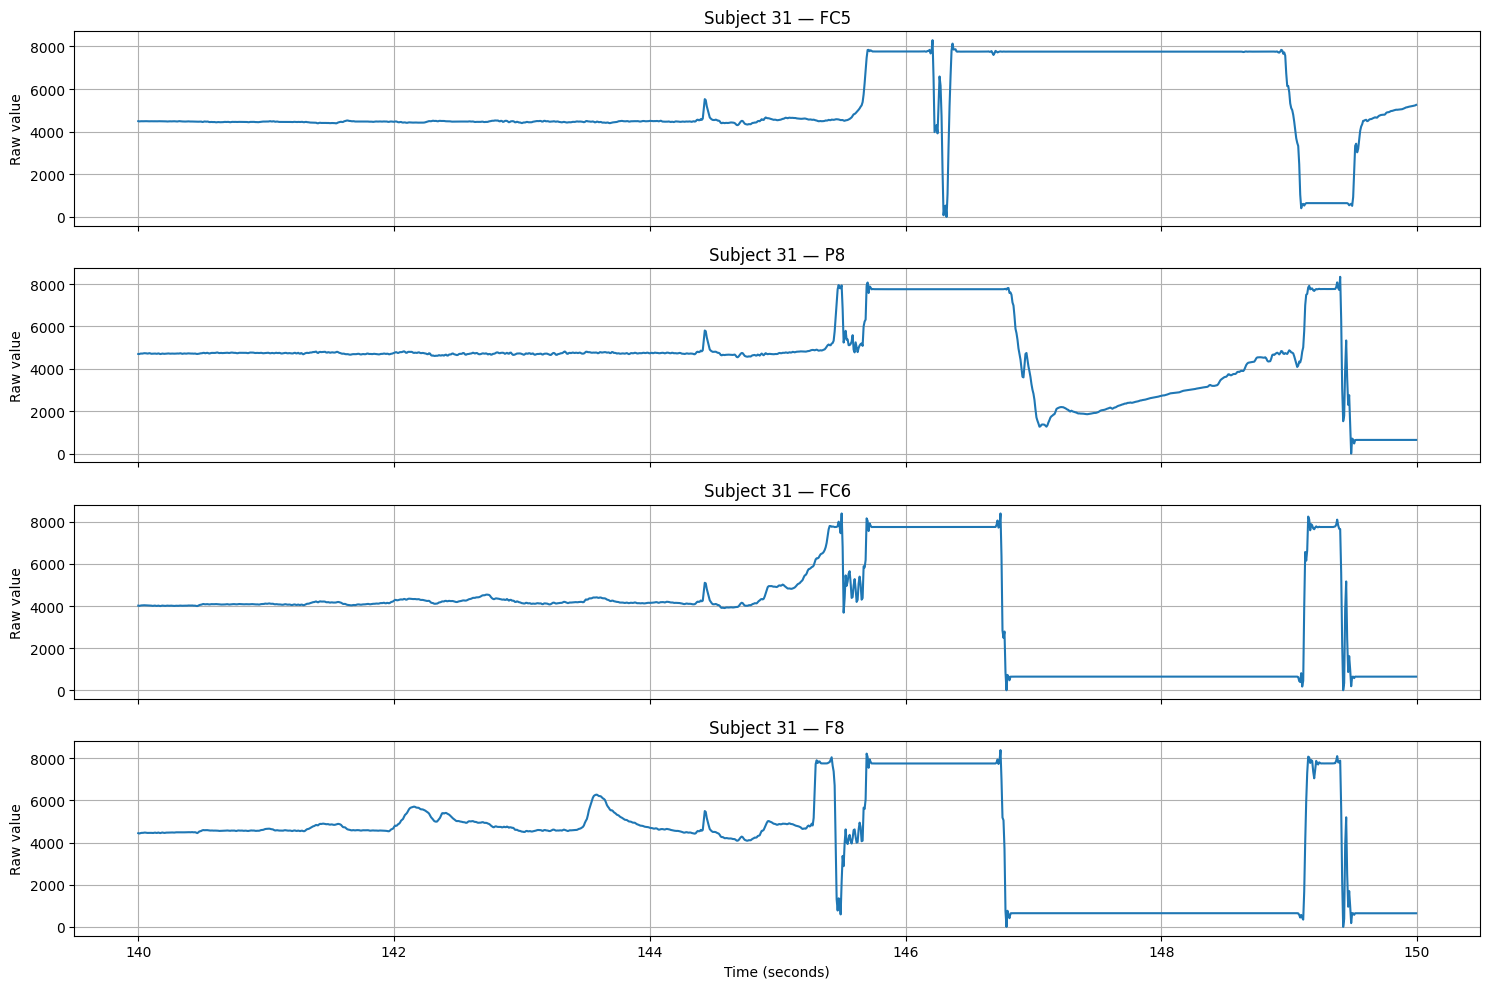

In [42]:
import numpy as np
import matplotlib.pyplot as plt

fs = 128

subject_idx = 30  # Subject 31
start_sample = 140 * fs
end_sample = 150 * fs

time = np.arange(start_sample, end_sample) / fs

channels_to_check = ["FC5", "P8", "FC6", "F8"]

channel_names = [
    "AF3", "F7", "F3", "FC5",
    "T7", "P7", "O1", "O2",
    "P8", "T8", "FC6", "F4",
    "F8", "AF4"
]

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

for ax, channel in zip(axes, channels_to_check):
    idx = channel_names.index(channel)

    ax.plot(
        time,
        X[idx, start_sample:end_sample, subject_idx]
    )

    ax.set_title(f"Subject 31 — {channel}")
    ax.set_ylabel("Raw value")
    ax.grid(True)

axes[-1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

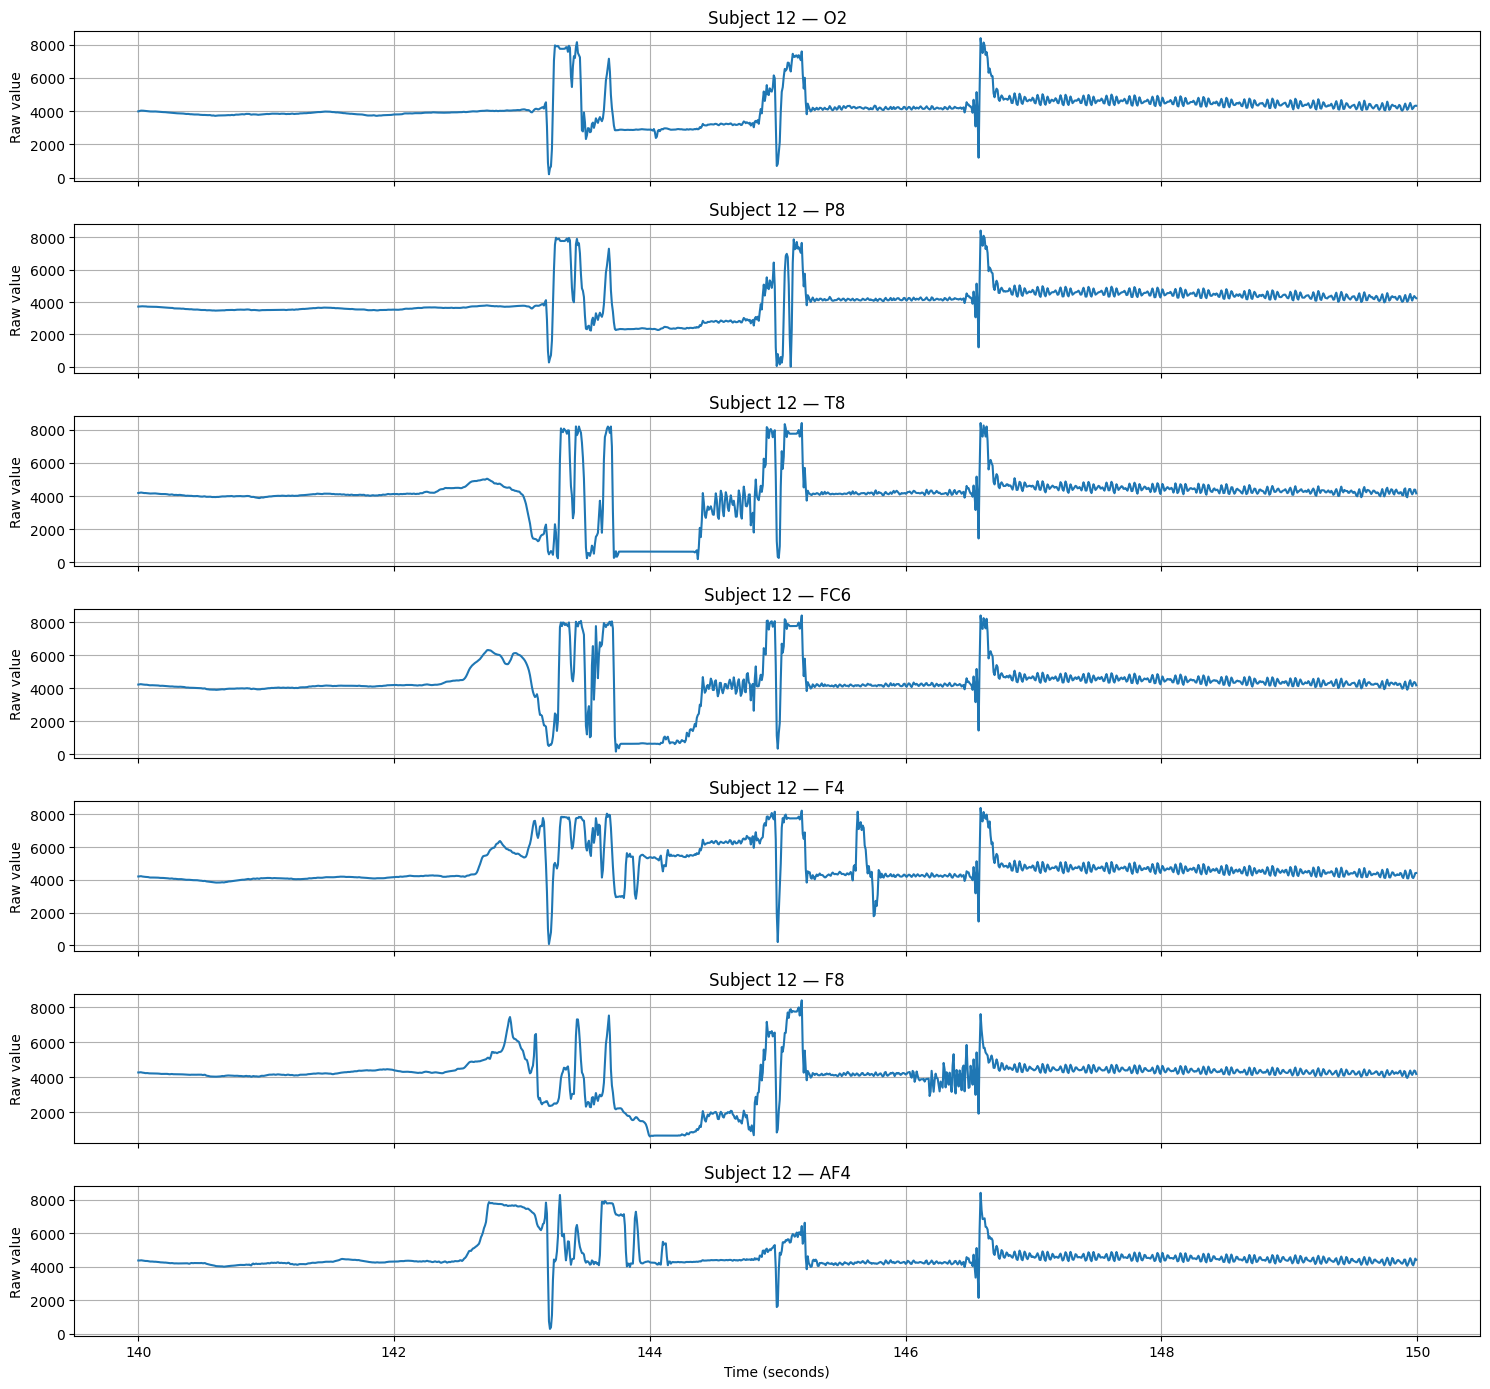

In [43]:
subject_idx = 11  # Subject 12

channels_to_check = [
    "O2", "P8", "T8",
    "FC6", "F4", "F8", "AF4"
]

fig, axes = plt.subplots(
    len(channels_to_check),
    1,
    figsize=(15, 14),
    sharex=True
)

for ax, channel in zip(axes, channels_to_check):
    idx = channel_names.index(channel)

    ax.plot(
        time,
        X[idx, start_sample:end_sample, subject_idx]
    )

    ax.set_title(f"Subject 12 — {channel}")
    ax.set_ylabel("Raw value")
    ax.grid(True)

axes[-1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

Visual inspection of Subjects 12 and 31 revealed extended abnormal signal regions near the end of their recordings. These regions included abrupt amplitude changes, prolonged plateaus, extreme signal values, and simultaneous disturbances across multiple channels. Although exact boundary values were rare, the surrounding abnormal regions suggest possible signal saturation, clipping, electrode-contact problems, or other recording artifacts. Therefore, artifact handling should consider complete signal windows rather than detecting only exact minimum and maximum values.

Create the band-pass filter

In [44]:
from scipy.signal import butter, sosfiltfilt

fs = 128

def bandpass_filter(signal_data, lowcut=1.0, highcut=40.0, fs=128, order=4):

    sos = butter(
        order,
        [lowcut, highcut],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered_signal = sosfiltfilt(sos, signal_data)

    return filtered_signal

Filter Subject 1 — AF3

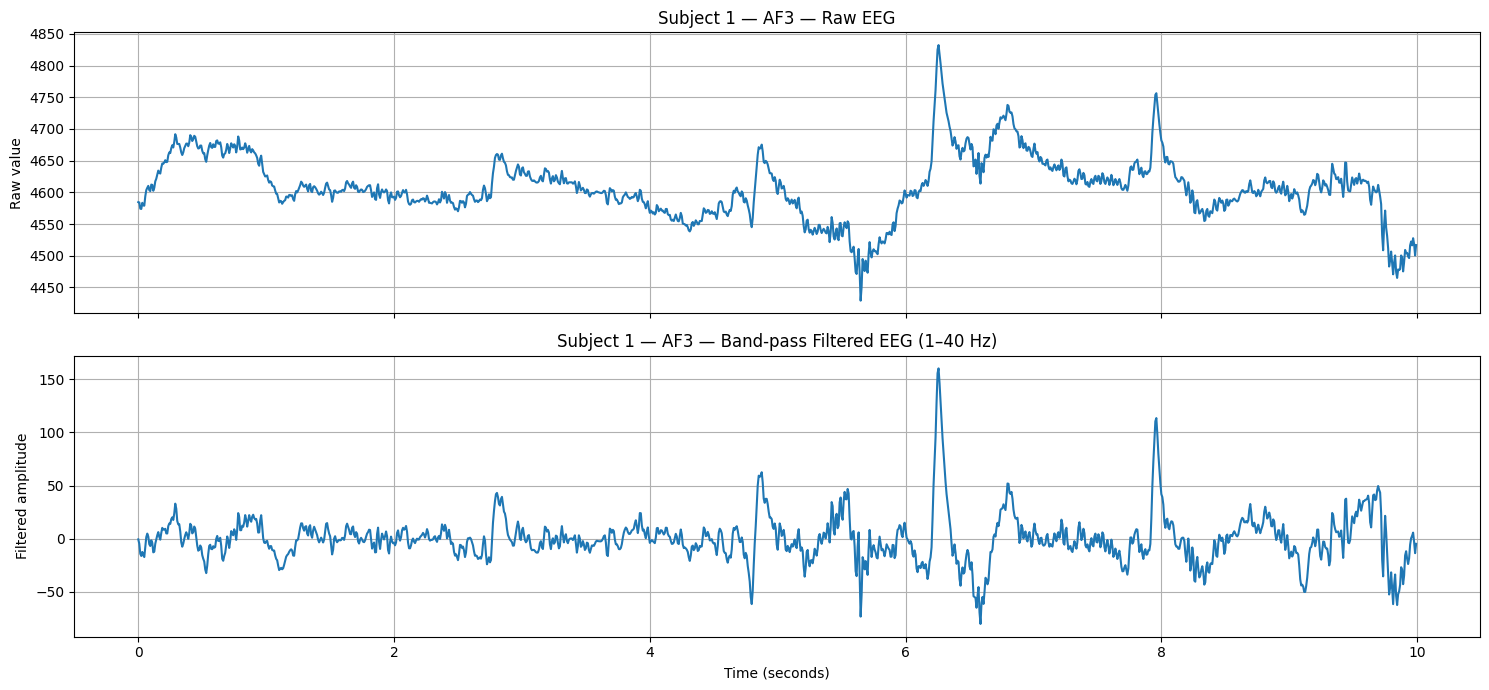

In [45]:
import numpy as np
import matplotlib.pyplot as plt

subject_idx = 0
channel_idx = 0   # AF3

raw_signal = X[channel_idx, :, subject_idx]

filtered_signal = bandpass_filter(
    raw_signal,
    lowcut=1,
    highcut=40,
    fs=128
)

duration = 10
end_sample = duration * fs

time = np.arange(end_sample) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(
    time,
    raw_signal[:end_sample]
)

axes[0].set_title(
    "Subject 1 — AF3 — Raw EEG"
)
axes[0].set_ylabel("Raw value")
axes[0].grid(True)


axes[1].plot(
    time,
    filtered_signal[:end_sample]
)

axes[1].set_title(
    "Subject 1 — AF3 — Band-pass Filtered EEG (1–40 Hz)"
)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Filtered amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Calculate before-and-after statistics

In [46]:
print("RAW SIGNAL")
print("Mean:", np.mean(raw_signal))
print("Std:", np.std(raw_signal))
print("Min:", np.min(raw_signal))
print("Max:", np.max(raw_signal))

print("\nFILTERED SIGNAL")
print("Mean:", np.mean(filtered_signal))
print("Std:", np.std(filtered_signal))
print("Min:", np.min(filtered_signal))
print("Max:", np.max(filtered_signal))

RAW SIGNAL
Mean: 4613.7930671875
Std: 563.3378496936378
Min: 2633.33
Max: 7816.41

FILTERED SIGNAL
Mean: -0.004178416757284175
Std: 114.60447527854902
Min: -1235.3964805390726
Max: 2416.651760323931


Test the filter on corrupted Subject 31

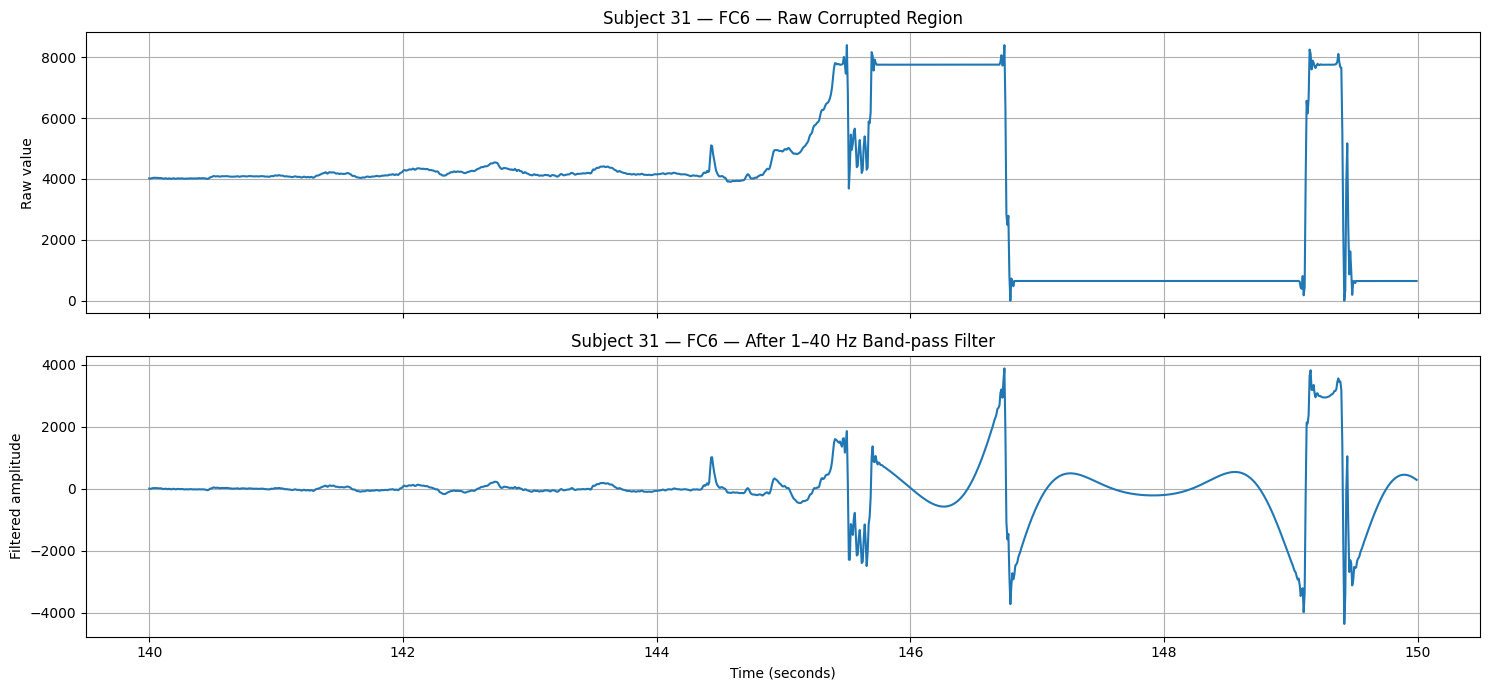

In [47]:

subject_idx = 30   # Subject 31
channel_idx = 10   # FC6

raw_corrupted = X[channel_idx, :, subject_idx]

filtered_corrupted = bandpass_filter(
    raw_corrupted,
    lowcut=1,
    highcut=40,
    fs=128
)

start_sample = 140 * fs
end_sample = 150 * fs

time = np.arange(start_sample, end_sample) / fs

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

axes[0].plot(
    time,
    raw_corrupted[start_sample:end_sample]
)

axes[0].set_title(
    "Subject 31 — FC6 — Raw Corrupted Region"
)
axes[0].set_ylabel("Raw value")
axes[0].grid(True)


axes[1].plot(
    time,
    filtered_corrupted[start_sample:end_sample]
)

axes[1].set_title(
    "Subject 31 — FC6 — After 1–40 Hz Band-pass Filter"
)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Filtered amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The 1–40 Hz band-pass filter successfully removed the large baseline offset and reduced slow drift and high-frequency components in the EEG signal. For relatively normal EEG regions, the filtered signal became approximately zero-centered while retaining temporal fluctuations. However, filtering did not repair severely corrupted regions. Abrupt discontinuities and plateau-like artifacts produced large responses after filtering, demonstrating that artifact detection and rejection must be performed separately from frequency filtering.

Step 3A: Calculate PSD using Welch's method

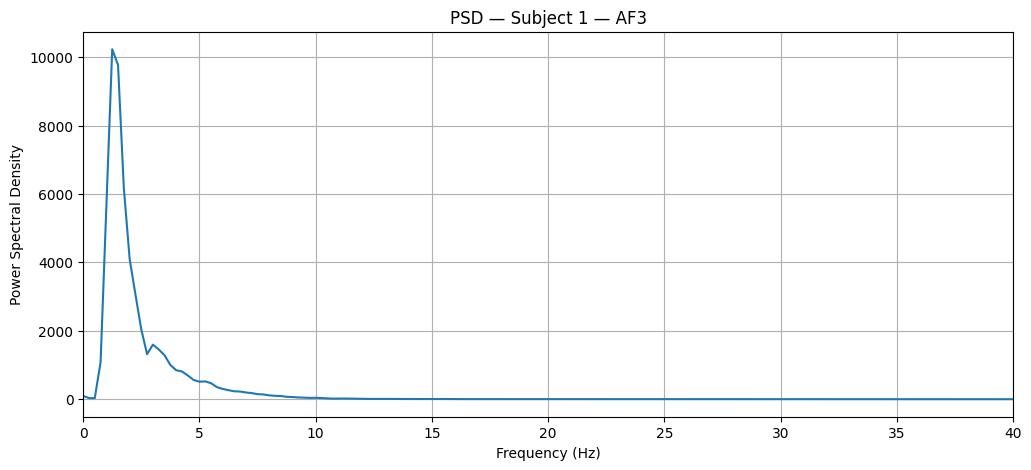

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 128

# Subject 1, AF3
subject_idx = 0
channel_idx = 0

raw_signal = X[channel_idx, :, subject_idx]

filtered_signal = bandpass_filter(
    raw_signal,
    lowcut=1,
    highcut=40,
    fs=fs
)

frequencies, psd = welch(
    filtered_signal,
    fs=fs,
    nperseg=512
)

plt.figure(figsize=(12, 5))

plt.plot(frequencies, psd)

plt.xlim(0, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD — Subject 1 — AF3")

plt.grid(True)
plt.show()

Show the EEG frequency bands

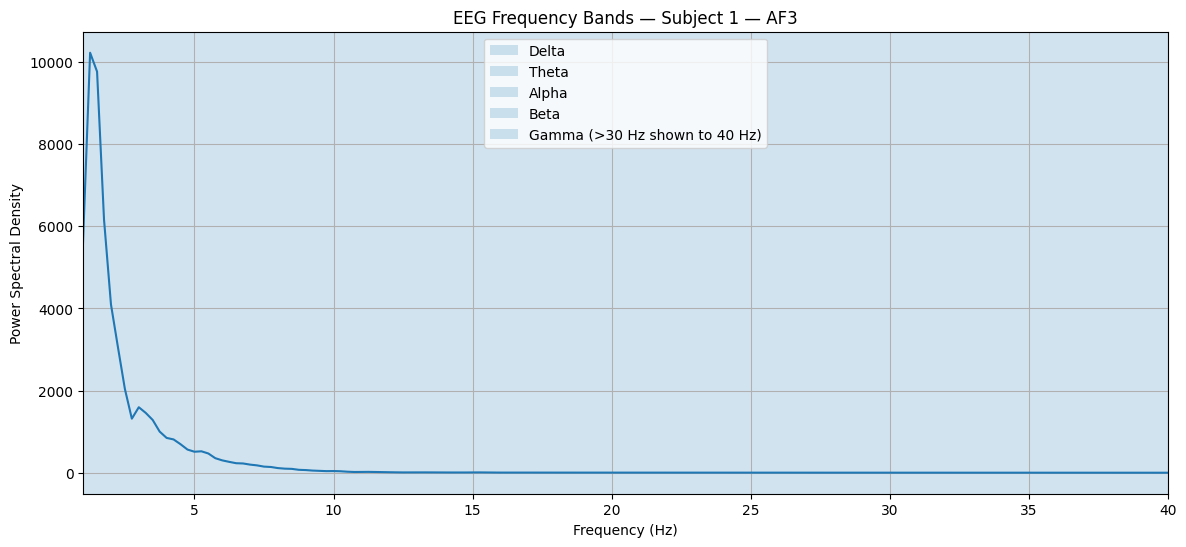

In [49]:
plt.figure(figsize=(14, 6))

plt.plot(frequencies, psd)

plt.axvspan(1, 4, alpha=0.2, label="Delta")
plt.axvspan(4, 8, alpha=0.2, label="Theta")
plt.axvspan(8, 13, alpha=0.2, label="Alpha")
plt.axvspan(13, 30, alpha=0.2, label="Beta")
plt.axvspan(30, 40, alpha=0.2, label="Gamma (>30 Hz shown to 40 Hz)")

plt.xlim(1, 40)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("EEG Frequency Bands — Subject 1 — AF3")

plt.legend()
plt.grid(True)

plt.show()

Calculate band power

In [50]:
bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma_30_40": (30, 40)
}

band_powers = {}

for band_name, (low, high) in bands.items():

    mask = (frequencies >= low) & (frequencies < high)

    power = np.trapezoid(
        psd[mask],
        frequencies[mask]
    )

    band_powers[band_name] = power


for band, power in band_powers.items():
    print(band, ":", power)

Delta : 11091.817692806097
Theta : 1491.4849618522153
Alpha : 186.0202819615954
Beta : 47.73049535498731
Gamma_30_40 : 10.754559169745596


Calculate relative band power

In [51]:
total_mask = (frequencies >= 1) & (frequencies <= 40)

total_power = np.trapezoid(
    psd[total_mask],
    frequencies[total_mask]
)

print("Relative Band Powers\n")

for band, power in band_powers.items():

    relative_power = power / total_power

    print(
        band,
        ":",
        relative_power
    )

Relative Band Powers

Delta : 0.8471409671675433
Theta : 0.11391261992331594
Alpha : 0.014207355903075416
Beta : 0.003645431174426421
Gamma_30_40 : 0.0008213827443654978


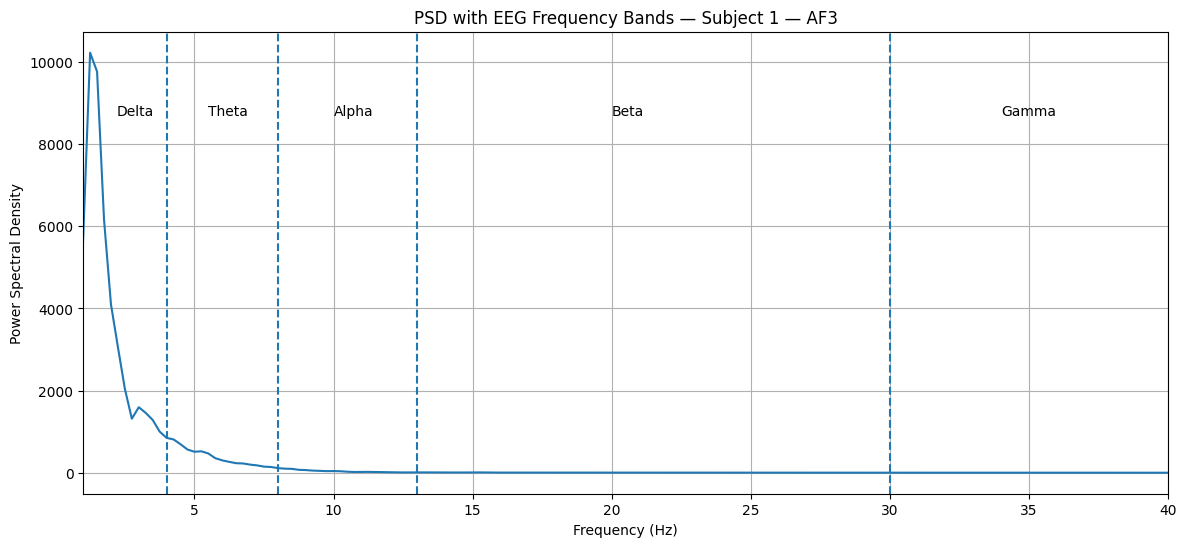

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(frequencies, psd)

plt.axvline(4, linestyle="--")
plt.axvline(8, linestyle="--")
plt.axvline(13, linestyle="--")
plt.axvline(30, linestyle="--")

plt.text(2.2, max(psd) * 0.85, "Delta")
plt.text(5.5, max(psd) * 0.85, "Theta")
plt.text(10, max(psd) * 0.85, "Alpha")
plt.text(20, max(psd) * 0.85, "Beta")
plt.text(34, max(psd) * 0.85, "Gamma")

plt.xlim(1, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("PSD with EEG Frequency Bands — Subject 1 — AF3")
plt.grid(True)

plt.show()

- Delta (1–4 Hz) has by far the highest power, with a very strong peak around 1–2 Hz.
- Theta (4–8 Hz) has the second-highest power, but it decreases quickly.
- Alpha (8–13 Hz) is weak in this AF3 recording, with no obvious alpha peak.
- Beta (13–30 Hz) has very low power.
- Gamma (30–40 Hz visible here) has almost no visible power at this scale.

The important point is that the graph is dominated by low-frequency activity. Because we already saw large slow excursions in Subject 1's AF3 raw signal, we should not assume all of this delta power is genuine neural delta activity; artifacts and slow signal changes may contribute.

PSD analysis showed that Subject 1's AF3 signal was dominated by low-frequency power, particularly in the 1–4 Hz range. Theta was the second strongest band, while alpha, beta, and 30–40 Hz power were substantially lower. Because the AF3 recording also contains large slow signal excursions, the low-frequency dominance should not be interpreted solely as neural delta activity. Artifact analysis and comparisons across subjects, channels, and workload classes are required.

Does Subject 1 show the same frequency pattern in AF3 and O1, or do the two scalp locations have different spectral profiles?

AF3 vs O1 PSD

In [53]:
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 128
subject_idx = 0  # Subject 1

# Channel indices
af3_idx = 0
o1_idx = 6

# Raw signals
af3_raw = X[af3_idx, :, subject_idx]
o1_raw = X[o1_idx, :, subject_idx]

# Filter complete signals
af3_filtered = bandpass_filter(
    af3_raw,
    lowcut=1,
    highcut=40,
    fs=fs
)

o1_filtered = bandpass_filter(
    o1_raw,
    lowcut=1,
    highcut=40,
    fs=fs
)

# Calculate PSD
freq_af3, psd_af3 = welch(
    af3_filtered,
    fs=fs,
    nperseg=512
)

freq_o1, psd_o1 = welch(
    o1_filtered,
    fs=fs,
    nperseg=512
)

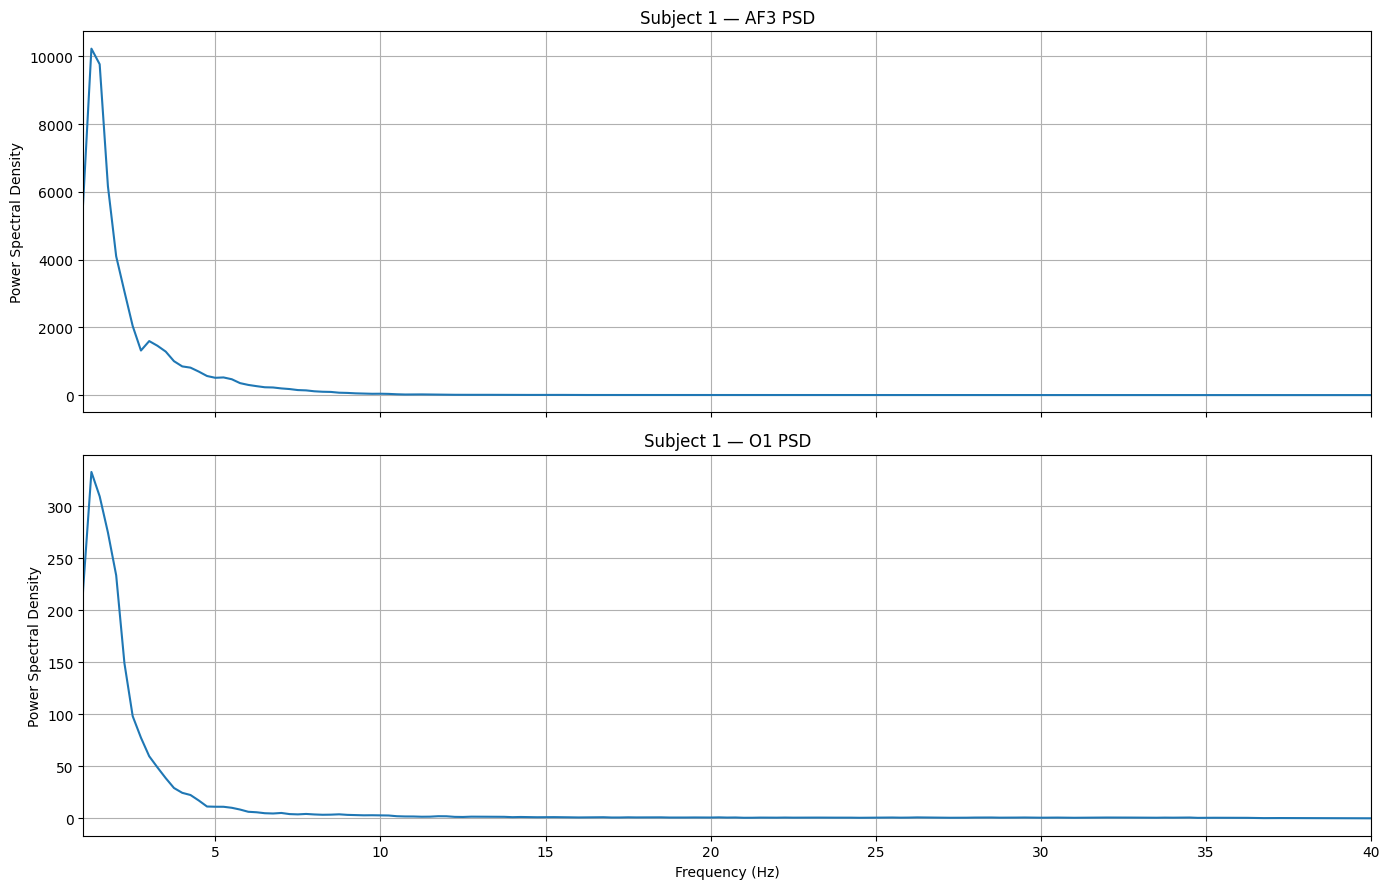

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# AF3
axes[0].plot(freq_af3, psd_af3)
axes[0].set_xlim(1, 40)
axes[0].set_title("Subject 1 — AF3 PSD")
axes[0].set_ylabel("Power Spectral Density")
axes[0].grid(True)

# O1
axes[1].plot(freq_o1, psd_o1)
axes[1].set_xlim(1, 40)
axes[1].set_title("Subject 1 — O1 PSD")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power Spectral Density")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Calculate band powers for both channels

In [55]:
import numpy as np

bands = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta": (13, 30),
    "Gamma_30_40": (30, 40)
}


def calculate_band_power(frequencies, psd):

    band_powers = {}

    total_mask = (
        (frequencies >= 1) &
        (frequencies <= 40)
    )

    total_power = np.trapezoid(
        psd[total_mask],
        frequencies[total_mask]
    )

    for band_name, (low, high) in bands.items():

        mask = (
            (frequencies >= low) &
            (frequencies < high)
        )

        absolute_power = np.trapezoid(
            psd[mask],
            frequencies[mask]
        )

        relative_power = absolute_power / total_power

        band_powers[band_name] = {
            "Absolute": absolute_power,
            "Relative": relative_power
        }

    return band_powers

In [56]:
af3_powers = calculate_band_power(
    freq_af3,
    psd_af3
)

o1_powers = calculate_band_power(
    freq_o1,
    psd_o1
)


print("AF3 BAND POWERS")

for band, values in af3_powers.items():
    print(
        band,
        "| Absolute:",
        values["Absolute"],
        "| Relative:",
        values["Relative"]
    )


print("\nO1 BAND POWERS")

for band, values in o1_powers.items():
    print(
        band,
        "| Absolute:",
        values["Absolute"],
        "| Relative:",
        values["Relative"]
    )

AF3 BAND POWERS
Delta | Absolute: 11091.817692806097 | Relative: 0.8471409671675433
Theta | Absolute: 1491.4849618522153 | Relative: 0.11391261992331594
Alpha | Absolute: 186.0202819615954 | Relative: 0.014207355903075416
Beta | Absolute: 47.73049535498731 | Relative: 0.003645431174426421
Gamma_30_40 | Absolute: 10.754559169745596 | Relative: 0.0008213827443654978

O1 BAND POWERS
Delta | Absolute: 437.2978906585536 | Relative: 0.8516839698561665
Theta | Absolute: 35.477398926494836 | Relative: 0.06909599292231802
Alpha | Absolute: 12.01002137926757 | Relative: 0.02339078899042469
Beta | Absolute: 15.003794271377922 | Relative: 0.029221478861259646
Gamma_30_40 | Absolute: 5.30571174288594 | Relative: 0.01033343571195474


Comparison of AF3 and O1 showed substantial channel-dependent differences in spectral power. AF3 exhibited considerably greater absolute power than O1, particularly at low frequencies. However, both channels were dominated by the 1–4 Hz range in terms of relative power. AF3 showed a larger relative theta contribution, whereas O1 showed larger relative contributions from alpha, beta, and 30–40 Hz activity. These findings demonstrate that EEG spectral characteristics vary across channels and that both absolute and relative power should be considered when comparing scalp locations.